# Riemannian interior-point methods for tensor scaling

This notebook showcases a prototype implementation of an interior-point method for tensor scaling, comparing it to other methods (gradient descent, and a damped version of a Newton method).

In [1]:
import numpy as np
from tensorscaling import scale, random_tensor, random_spectrum
from ipm import scale_ipm
import time

Below is an example showcasing scaling random tensors of a given shape to random marginals.

In [2]:
shape = (4,4,4)
rand_T = random_tensor(shape)
rand_targets = { k : random_spectrum(n) for k, n in enumerate(shape)} 
rand_eps = 0.000001
T, targets, eps = rand_T, rand_targets, rand_eps
print(f"targets: {rand_targets}")

targets: {0: array([0.62, 0.19, 0.13, 0.06]), 1: array([0.58, 0.25, 0.14, 0.03]), 2: array([0.48, 0.36, 0.14, 0.02])}


## Various methods
We first use gradient descent:

In [3]:
# method 1: gradient descent
start = time.perf_counter()
result, max_dists_grad = scale(T / np.linalg.norm(T), targets, eps, method="gradient", max_iterations=10000)
stop = time.perf_counter()
time_grad = stop-start
print(result)
print(f"elapsed time: {time_grad:0.4f}s")

Result(success=True, iterations=3468, max_dist=9.976829908433726e-07, ..., log_cap=-0.7053480289285252)
elapsed time: 1.5352s


Next, we try the damped Newton method directly on the shifted Kempf--Ness function:

In [4]:
# method 2: damped Newton method on the shifted Kempf--Ness function
start = time.perf_counter()
result, max_dists_damped = scale_ipm(T, targets, eps, method="damped_newton")
stop = time.perf_counter()
time_damped = stop-start
print(result)
print(f"elapsed time: {time_damped:0.4f}s")
print("-log(max_dist) per iteration:", -np.log(max_dists_damped))

Result(success=True, iterations=7, max_dist=2.8688070831271537e-07, ..., log_cap=-2.4660415408560645)
elapsed time: 1.8814s
-log(max_dist) per iteration: [ 1.31743202  1.63232     2.18803885  2.25917517  2.94562674  5.77304349
  9.03577108 15.06419936]


Lastly, we run the interior-point method:

In [5]:
# method 3: long-step interior point method
start = time.perf_counter()
result, max_dists_ipm = scale_ipm(T, targets, eps, long_step=True, method="ipm", initial_radius=20,max_outer_iterations=0)
stop = time.perf_counter()
print(result)
print(f"elapsed time: {stop-start:0.4f}s")
time_ipm = stop-start
print("-log(max_dist) per iteration:", -np.log(max_dists_ipm))

Result(success=True, iterations=111, max_dist=7.142984817054614e-07, ..., log_cap=-2.466033910225696)
elapsed time: 29.5627s
-log(max_dist) per iteration: [ 1.31743202  1.31886001  1.32169195  1.32563011  1.3308454   1.3375728
  1.34608628  1.35684931  1.36994582  1.38537082  1.40314553  1.42269902
  1.44406038  1.46665458  1.49090945  1.51651769  1.5431633   1.56920841
  1.59692881  1.62483461  1.65265749  1.6801599   1.7088244   1.73688941
  1.75891081  1.77852075  1.79949814  1.82029665  1.84219763  1.86519038
  1.88925418  1.91256313  1.93675957  1.9618583   1.98785989  2.01267494
  2.03825113  2.06460219  2.09172959  2.11963321  2.14831113  2.17775921
  2.20797091  2.23893717  2.27064638  2.30308451  2.33623529  2.37008044
  2.40460003  2.43977272  2.47557617  2.5119873   2.54898263  2.58653855
  2.62463154  2.66323843  2.70564033  2.74856504  2.79201195  2.83595417
  2.88036703  2.92522703  2.97051193  3.0190216   3.06670756  3.11471007
  3.16301301  3.21160341  3.26397328  3.316

## Visualizing the results

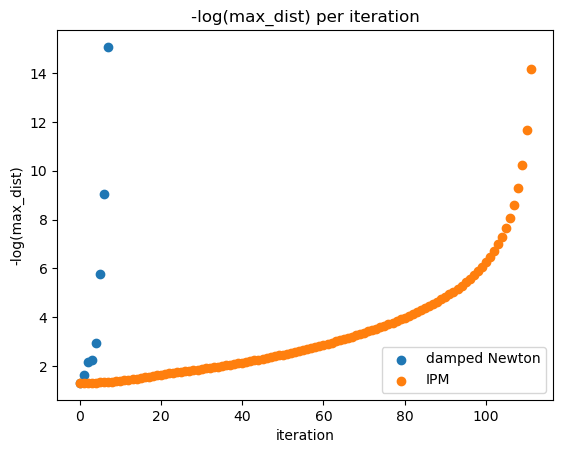

In [6]:
import matplotlib.pyplot as plt
plt.title("-log(max_dist) per iteration")
plt.scatter(range(len(max_dists_damped)), -np.log(max_dists_damped), label="damped Newton")
plt.scatter(range(len(max_dists_ipm)), -np.log(max_dists_ipm), label="IPM")
plt.legend()
plt.xlabel("iteration")
plt.ylabel("-log(max_dist)")
plt.show()

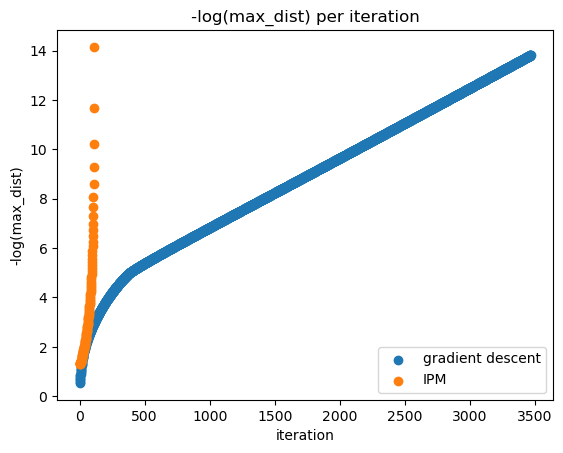

In [7]:
plt.title("-log(max_dist) per iteration")
plt.scatter(range(len(max_dists_grad)), -np.log(max_dists_grad), label="gradient descent")
plt.scatter(range(len(max_dists_ipm)), -np.log(max_dists_ipm), label="IPM")
plt.legend()
plt.xlabel("iteration")
plt.ylabel("-log(max_dist)")
plt.show()

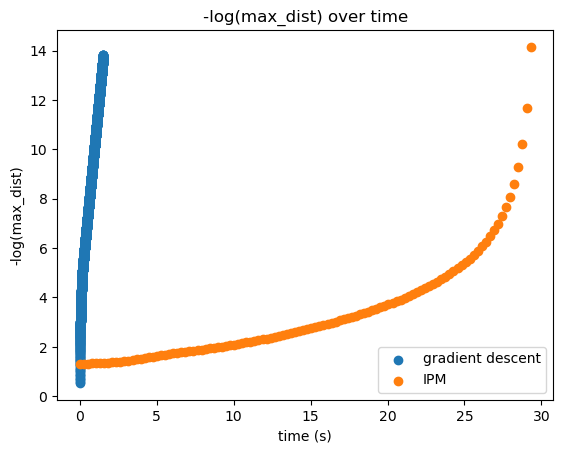

In [8]:
plt.title("-log(max_dist) over time")
plt.scatter(np.arange(len(max_dists_grad)) / len(max_dists_grad) * time_grad, -np.log(max_dists_grad), label="gradient descent")
plt.scatter(np.arange(len(max_dists_ipm)) / len(max_dists_ipm) * time_ipm, -np.log(max_dists_ipm), label="IPM")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("-log(max_dist)")
plt.show()

## Other examples
Here are some other examples that one can try.
Below is an example showcasing scaling the W-state to a maximally entangled state on the first two parties.

In [ ]:
# scale W to an EPR pair on the first two parties
W = np.array([[[0,1],[1,0]],
              [[1,0],[0,0]]])
W_targets =  { 0: (1/2,1/2), 1: (1/2,1/2), 2: (1,0) }
W_eps = 0.0001
T, targets, eps = W, W_targets, W_eps

Below is an example showcasing scaling random tensors of a given shape to achievable uniform marginals.

In [ ]:
# random tensor as example, with different targets
shape = (2,3,4)
rand_T = random_tensor(shape)
rand_targets = { 0 : (1/2,1/2), 1: (1/3,1/3,1/3), 2: (1/2,1/6,1/6,1/6) } 
rand_eps = 0.000001
T, targets, eps = rand_T, rand_targets, rand_eps